# Lab 2: ephys - MT - with bigquery integration

Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

/Users/sspivack/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
%load_ext google.cloud.bigquery
client = bigquery.Client() 

In [3]:
%%bigquery mt
  select
    trial_id,
    (select array_agg(cast(x as float64)) from unnest(json_extract_array(spike_times)) as x) as spike_times,
    condition_id,
    condition_angle,
    unit_label
  from neural-ds-fe73.lab1_ephys.mt

Query is running:   0%|          |

Downloading:   0%|          |

In [4]:
mt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   trial_id         179 non-null    Int64  
 1   spike_times      179 non-null    object 
 2   condition_id     179 non-null    float64
 3   condition_angle  179 non-null    float64
 4   unit_label       179 non-null    object 
dtypes: Int64(1), float64(2), object(2)
memory usage: 7.3+ KB


#### 1) 1 raster (1 trial)

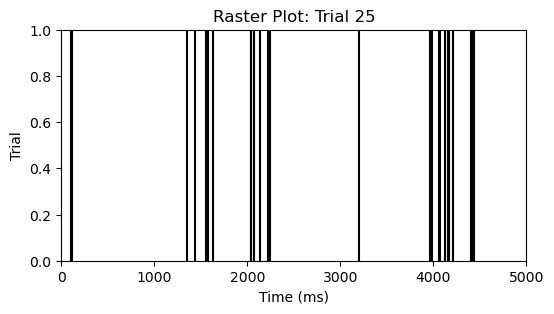

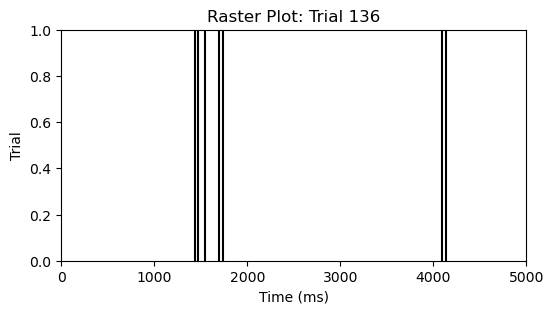

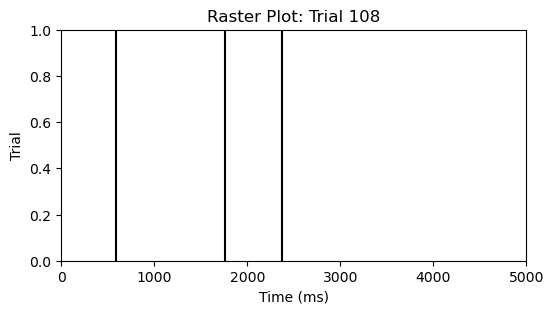

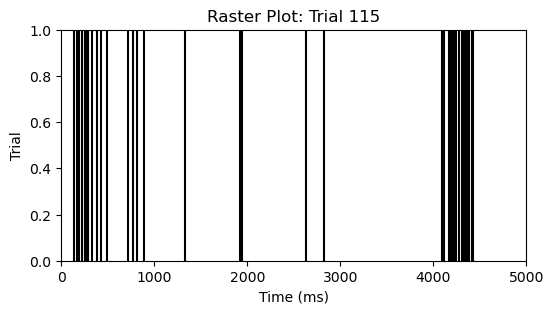

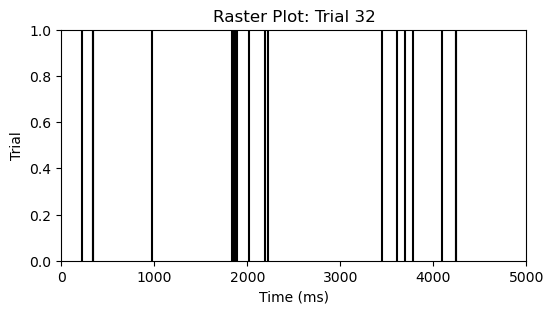

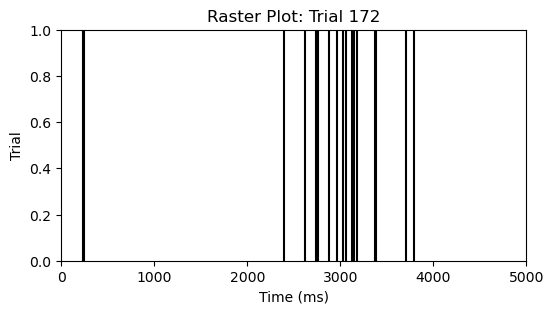

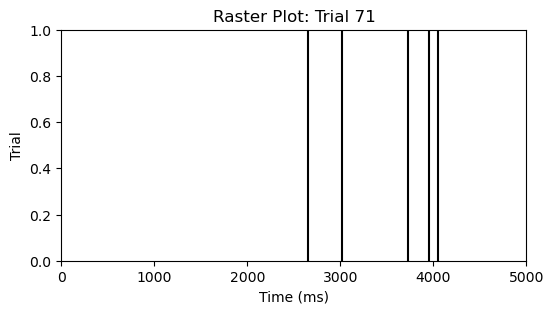

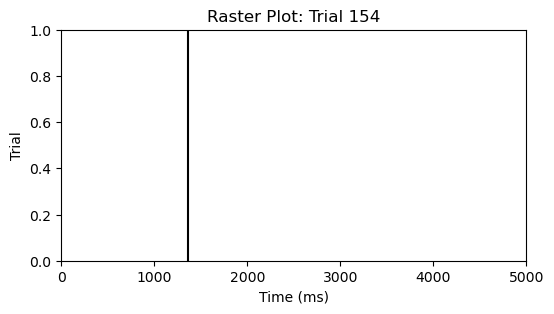

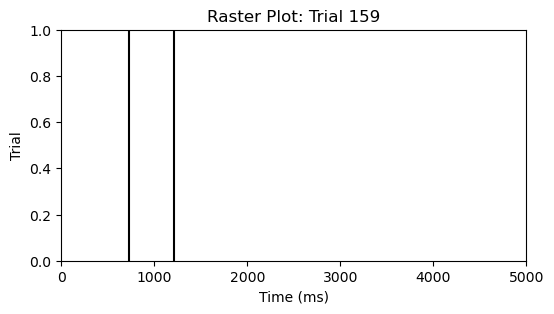

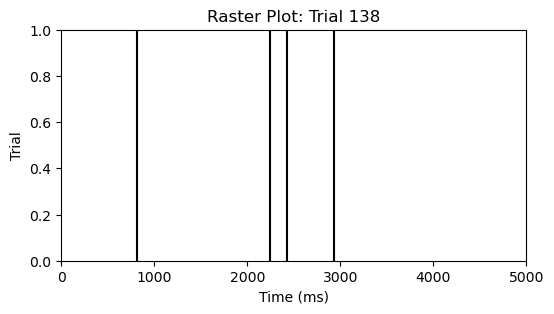

In [5]:
# --- Loop through 10 examples ---
for i in range(10):   
    
    # --- Pick a random trial index ---
    trial_index = np.random.randint(0, len(mt)) # pick a random number, 0 to 178
    trial_id = mt.loc[trial_index, "trial_id"] # trial index -> trial id
    spikes = np.array(mt.loc[trial_index, "spike_times"]) # get array of spikes

    # --- Plot ---
    plt.figure(figsize=(6, 3)) # you can adjust fig size here
    for spike in spikes: # loop through each spike in the array
        plt.vlines(spike, ymin=0, ymax=1, color='black') # plot vertical line -> needs: data, ymin/ymax
    plt.ylim(0, 1)
    plt.xlim(0, 5000)
    plt.xlabel("Time (ms)")
    plt.ylabel("Trial")
    plt.title(f"Raster Plot: Trial {trial_id}")
    plt.show()


#### 2) All rasters from one condition (all trials)

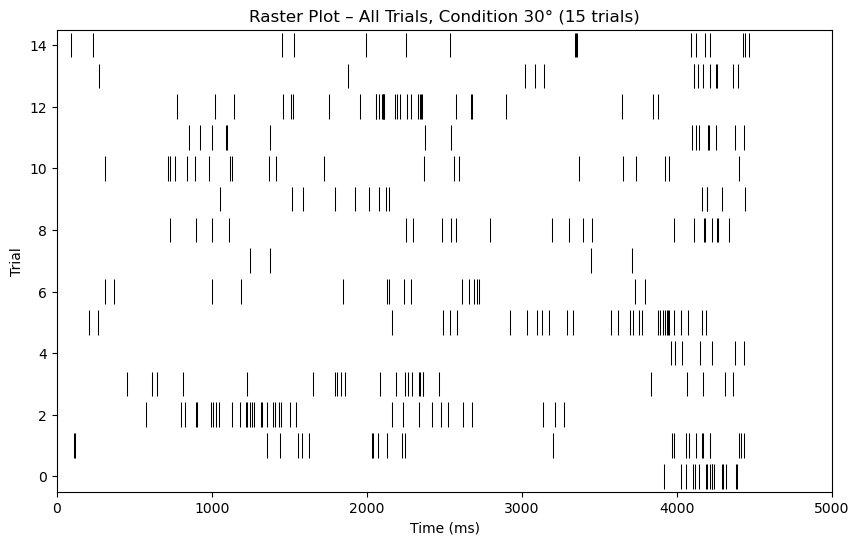

In [6]:
# --- Choose condition ---
chosen_angle = 30  # You can change this (0–330 in 30 degree steps)

# --- Filter trials with that condition_angle ---
subset = mt[mt["condition_angle"] == chosen_angle].reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(10, 6))
for i, row in subset.iterrows(): # iterrows gives us index and series for each iteration
    spikes = np.array(row["spike_times"]) # get array of spikes
    plt.vlines(spikes, i - 0.4, i + 0.4, color='black', linewidth=0.75) # plot vline with some buffer
plt.xlim(0, 5000)
plt.ylim(-0.5, len(subset) - 0.5)
plt.xlabel("Time (ms)")
plt.ylabel("Trial")
plt.title(f"Raster Plot – All Trials, Condition {chosen_angle}° ({len(subset)} trials)")
plt.show()


#### 3) The corresponding PSTH

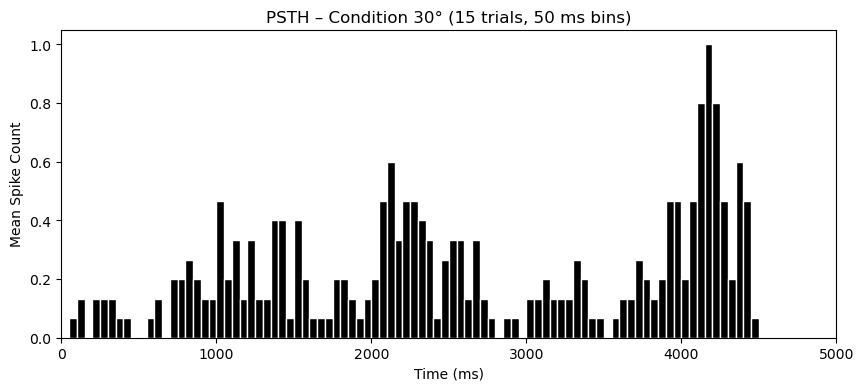

In [7]:
# --- Choose condition ---
chosen_angle = 30  # You can change this (0–330 in 30 degree steps)

# --- Filter trials ---
subset = mt[mt["condition_angle"] == chosen_angle].reset_index(drop=True)

# --- PSTH parameters ---
bin_size = 50  # in ms
time_range = (0, 5000) # 0 to 5000ms
bins = np.arange(time_range[0], time_range[1] + bin_size, bin_size) # array of bin values
bin_centers = bins[:-1] + bin_size / 2 # corresponding bin centers (take left edge per bin -> shift by half bin)

# --- Compute histogram per trial ---
spike_matrix = [] # init empty list
for _, row in subset.iterrows(): # ignore index, keep row
    spikes = np.array(row["spike_times"]) # extract spikes as array
    spikes = spikes[(spikes >= time_range[0]) & (spikes <= time_range[1])] # restrict to time window
    counts, _ = np.histogram(spikes, bins=bins) # count spikes per bin for this trial
    spike_matrix.append(counts) # append to list

spike_matrix = np.array(spike_matrix)  # shape: (n_trials, n_bins)
mean_psth = spike_matrix.mean(axis=0) # average downs rows [ axis=0 (rows/trials); axis=1 (colums/bins) ]

# --- Plot PSTH ---
plt.figure(figsize=(10, 4))
plt.bar(bin_centers, mean_psth, width=bin_size, color='black', edgecolor='white') 

plt.xlim(time_range)
plt.xlabel("Time (ms)")
plt.ylabel("Mean Spike Count")
plt.title(f"PSTH – Condition {chosen_angle}° ({len(subset)} trials, {bin_size} ms bins)")
plt.show()


#### 4) All the PSTHs

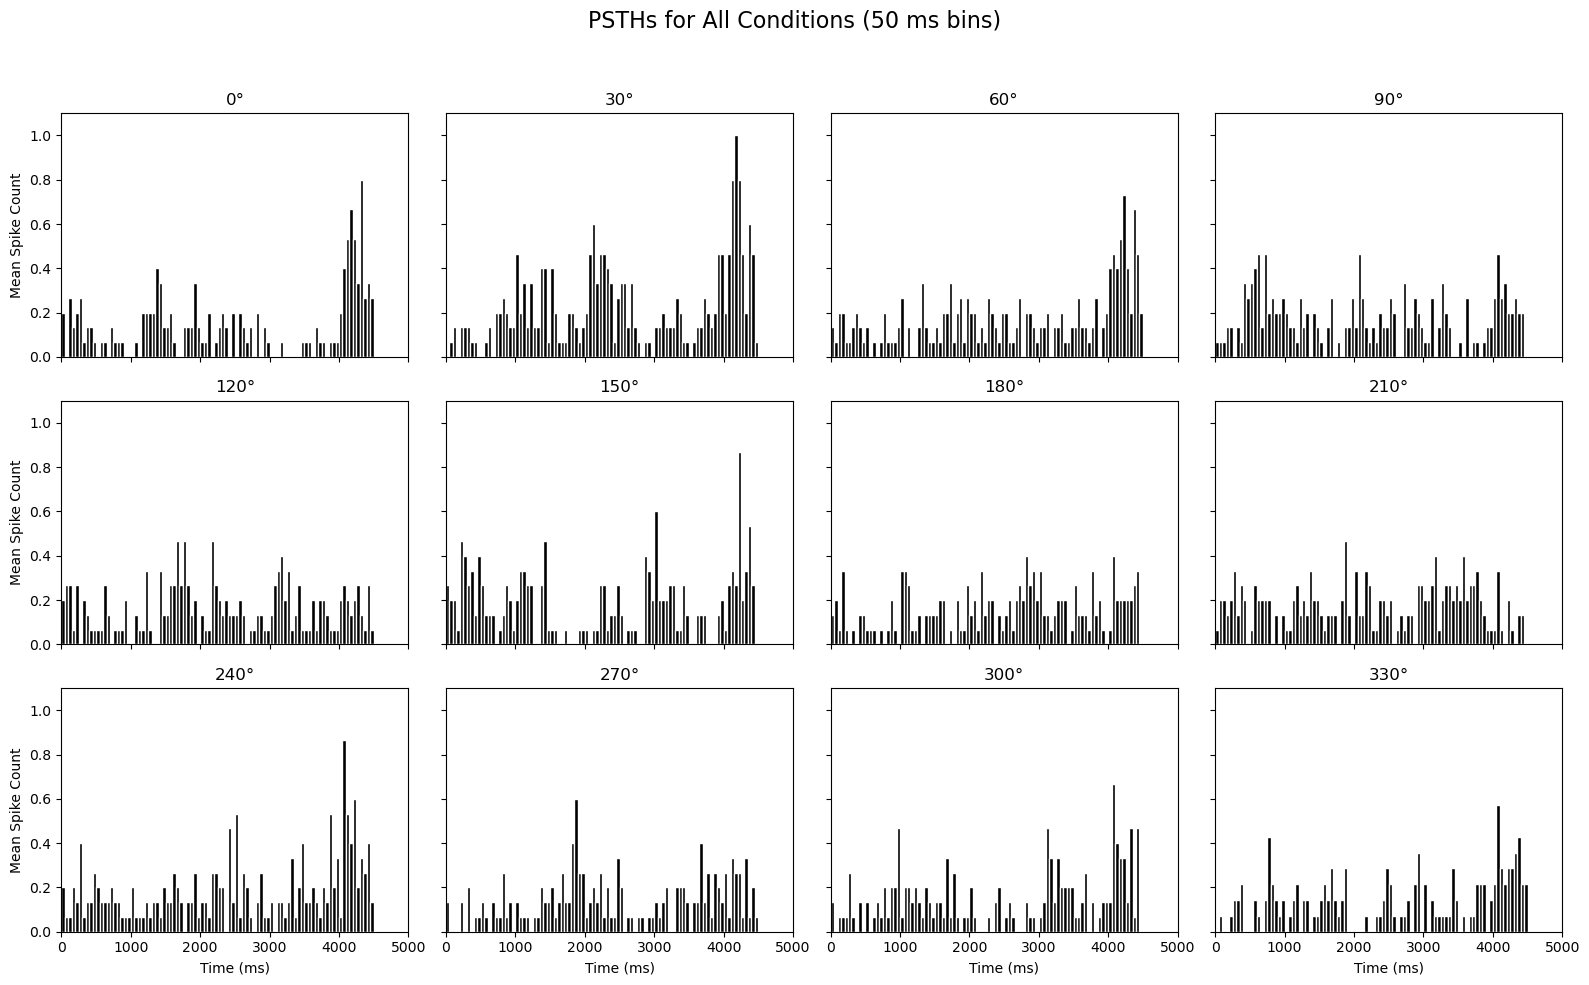

In [8]:
# --- Define parameters ---
condition_angles = np.arange(0, 360, 30) # array of thetas 0 to 330, 30 degree increments
bin_size = 50 # choose bin width
time_range = (0, 5000) # choose temporal window
bins = np.arange(time_range[0], time_range[1] + bin_size, bin_size) # bins, time_range[0] to time_range[1]
bin_centers = bins[:-1] + bin_size / 2 # same trick as before to get the centers

# --- Compute PSTHs ---
psth_dict = {} # init empty dict
max_count = 0 # use this to keep track of y-axis scale during plotting

for angle in condition_angles: # loop through each theta
    subset = mt[mt["condition_angle"] == angle].reset_index(drop=True) # extract subset of data
    spike_matrix = [] # init empty list

    for _, row in subset.iterrows():  # loop through each trial (ignore index)
        spikes = np.array(row["spike_times"])  # get spike times as array
        spikes = spikes[(spikes >= time_range[0]) & (spikes <= time_range[1])]  # keep spikes in window
        counts, _ = np.histogram(spikes, bins=bins)  # histogram: spikes per bin
        spike_matrix.append(counts)  # append trial’s histogram to list

    if spike_matrix:  # if there are trials for this angle
        spike_matrix = np.array(spike_matrix)  # convert to 2D array (trials × bins)
        mean_psth = spike_matrix.mean(axis=0)  # average across trials
    else:  # if no trials for this angle
        mean_psth = np.zeros(len(bins) - 1)  # empty PSTH (all zeros)

    psth_dict[angle] = mean_psth  # store PSTH for this angle
    max_count = max(max_count, mean_psth.max())  # update global max for y-axis scaling

# --- Plot 3×4 PSTHs ---
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)  # make 3x4 grid of subplots
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, angle in enumerate(condition_angles):  # loop over angles and subplot index
    ax = axes[i]  # pick the right subplot
    ax.bar(bin_centers, psth_dict[angle], width=bin_size, color='black', edgecolor='white')  # plot bar PSTH
    ax.set_title(f"{angle}°")  # add title with angle
    ax.set_xlim(time_range)  # x-axis = time window
    ax.set_ylim(0, max_count * 1.1)  # y-axis = common scale with padding

    if i >= 8:  # bottom row -> add x-label
        ax.set_xlabel("Time (ms)")
    if i % 4 == 0:  # first column -> add y-label
        ax.set_ylabel("Mean Spike Count")

fig.suptitle("PSTHs for All Conditions (50 ms bins)", fontsize=16)  # overall title
plt.tight_layout(rect=[0, 0, 1, 0.95])  # adjust layout to fit title
plt.show() 


#### 5) The Cartesian tuning curve

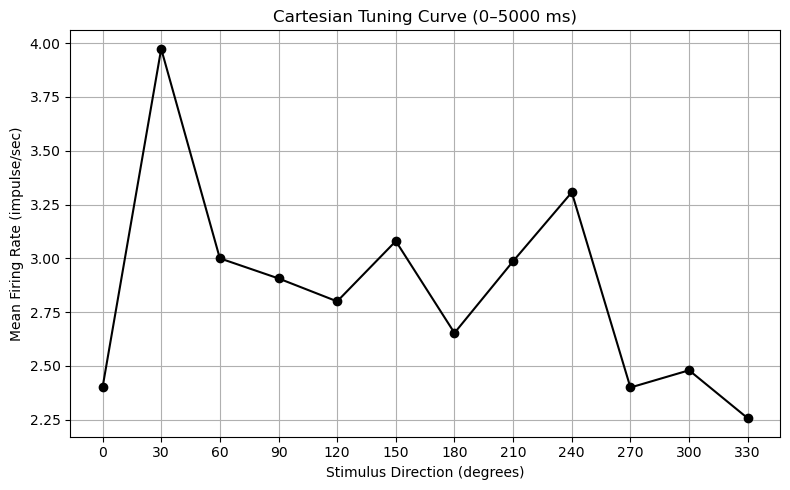

In [9]:
# --- Define ---
condition_angles = np.arange(0, 360, 30)  # stimulus directions 0–330 in 30 degree steps

# Define window (ms)
start_ms = 0    
stop_ms = 5000    
trial_duration_s = (stop_ms - start_ms) / 1000.0  # trial length in seconds

mean_rates = []  # store mean firing rates for each angle

# --- Compute mean firing rate per condition ---
for angle in condition_angles:  # loop through directions
    subset = mt[mt["condition_angle"] == angle].reset_index(drop=True)  # trials for this direction

    total_spikes = 0  # accumulator for spikes
    for _, row in subset.iterrows():  # loop through trials; keep rows, ignore index
        spikes = np.array(row["spike_times"])  # get spike times as array
        spikes = spikes[(spikes >= start_ms) & (spikes <= stop_ms)]  # restrict to window
        total_spikes += len(spikes)  # count spikes in this trial using iterative summing

    n_trials = len(subset)  # number of trials at this angle
    if n_trials > 0:  # avoid divide-by-zero
        mean_rate = total_spikes / n_trials / trial_duration_s  # mean spikes/sec
    else:  # if no trials
        mean_rate = 0

    mean_rates.append(mean_rate)  # save rate for this angle

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(condition_angles, mean_rates, marker='o', color='black')  # plot tuning curve
plt.xticks(condition_angles)  # ticks at each direction
plt.xlabel("Stimulus Direction (degrees)")  
plt.ylabel("Mean Firing Rate (impulse/sec)") 
plt.title(f"Cartesian Tuning Curve ({start_ms}–{stop_ms} ms)")  # add title with window
plt.grid(True)  # add grid
plt.tight_layout()  # tidy spacing
plt.show() 


#### 6) Adding errorbars

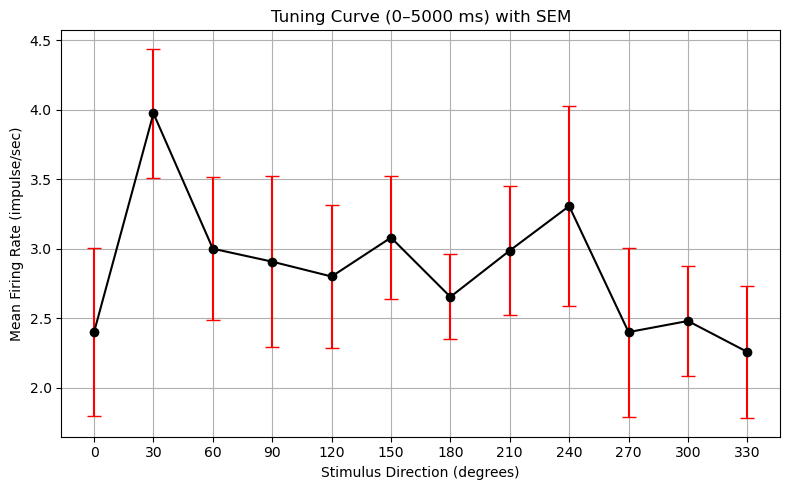

In [10]:
# --- Setup ---
condition_angles = np.arange(0, 360, 30)  # stimulus directions 0–330 in 30 degree steps

# Define window (ms)
start_ms = 0
stop_ms = 5000
trial_duration_s = (stop_ms - start_ms) / 1000.0  # trial length in seconds

mean_rates = []  # store mean rates per condition
sem_rates = []   # store SEM per condition

# --- Compute mean + SEM ---
for angle in condition_angles:  # loop through directions
    subset = mt[mt["condition_angle"] == angle].reset_index(drop=True)  # trials at this direction

    trial_rates = []  # rates for each trial
    for _, row in subset.iterrows():  # loop through trials
        spikes = np.array(row["spike_times"])  # get spike times
        spikes = spikes[(spikes >= start_ms) & (spikes <= stop_ms)]  # restrict to window
        rate = len(spikes) / trial_duration_s  # convert to firing rate
        trial_rates.append(rate)  # append trial rate

    if len(trial_rates) > 0:  # if trials exist
        mean = np.mean(trial_rates)  # mean firing rate
        sem = np.std(trial_rates, ddof=1) / np.sqrt(len(trial_rates))  # standard error of mean [ std/sqrt(n) ]
    else:  # if no trials
        mean, sem = 0, 0

    mean_rates.append(mean)  # save mean for this angle
    sem_rates.append(sem)    # save SEM for this angle

# --- Plot ---
plt.figure(figsize=(8, 5))  # make figure
plt.errorbar(
    condition_angles,
    mean_rates,
    yerr=sem_rates,        # vertical error bars = SEM
    fmt='-o',              # line with circle markers
    color='black',         # line/marker color
    ecolor='red',          # error bar color
    capsize=5,             # cap length on error bars
    linewidth=1.5          # line width
)

plt.xticks(condition_angles)  # ticks at each direction
plt.xlabel("Stimulus Direction (degrees)")
plt.ylabel("Mean Firing Rate (impulse/sec)") 
plt.title(f"Tuning Curve ({start_ms}–{stop_ms} ms) with SEM") 
plt.grid(True)  # add grid
plt.tight_layout()  # tidy spacing
plt.show()  # display


#### 7) The polar plot

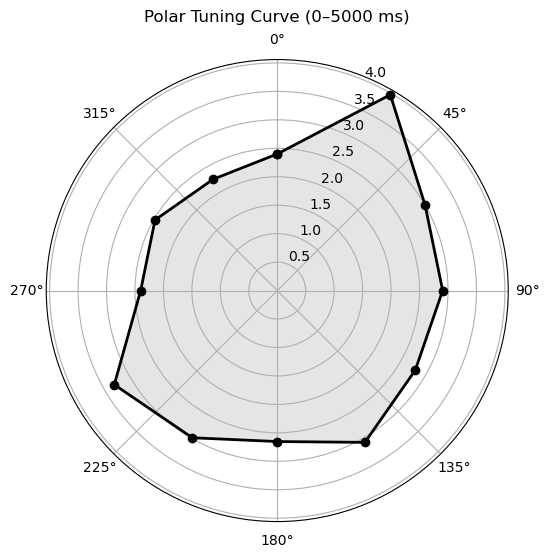

In [11]:
# --- Use the same inputs from step 6 ---
condition_angles = np.arange(0, 360, 30)  # stimulus directions 0–330 in 30 degree steps

# Define window (ms)
start_ms = 0       
stop_ms = 5000    
trial_duration_s = (stop_ms - start_ms) / 1000.0  # trial length in seconds

mean_rates = []  # store mean firing rates

# --- Compute mean firing rate per condition ---
for angle in condition_angles:  # loop through directions
    subset = mt[mt["condition_angle"] == angle].reset_index(drop=True)  # trials for this angle

    trial_rates = []  # firing rates per trial
    for _, row in subset.iterrows():  # loop through trials
        spikes = np.array(row["spike_times"])  # get spike times
        spikes = spikes[(spikes >= start_ms) & (spikes <= stop_ms)]  # restrict to window
        rate = len(spikes) / trial_duration_s  # convert to firing rate
        trial_rates.append(rate)

    mean = np.mean(trial_rates) if trial_rates else 0  # mean rate (0 if no trials)
    mean_rates.append(mean)  # append rate for this angle

# --- Convert to radians and close the circle ---
theta = np.deg2rad(np.append(condition_angles, condition_angles[0]))  # angles in radians, loop back to start
r = np.append(mean_rates, mean_rates[0])  # same for rates, loop back to start

# --- Plot ---
plt.figure(figsize=(6, 6))  # make square figure
ax = plt.subplot(111, polar=True)  # polar plot
ax.plot(theta, r, marker='o', color='black', linewidth=2)  # plot tuning curve
ax.fill(theta, r, color='black', alpha=0.1)  # fill area under curve

ax.set_theta_zero_location('N')   # 0 degree at the top (north)
ax.set_theta_direction(-1)        # clockwise direction
ax.set_title(f"Polar Tuning Curve ({start_ms}–{stop_ms} ms)", va='bottom')  # add title
plt.show() 
